# Flight Ticket Price Prediction — MLP Kaggle Assignment 1

**Goal:** Predict the price of a flight ticket given features about the airline, route, timing, stops, class, duration and days left before departure.

**Notebook roadmap**
1. Load data & identify data types
2. Descriptive statistics of numerical columns
3. Missing value analysis & handling
4. Duplicate analysis & handling
5. Outlier analysis & handling
6. Exploratory visualizations & insights
7. Feature scaling & encoding
8. Model building (7+ models)
9. Hyperparameter tuning (3 models)
10. Model comparison
11. Going further: feature engineering + a blended model for a higher R²
12. Final predictions


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print('Train shape:', train.shape)
print('Test shape :', test.shape)
train.head()


Train shape: (40000, 12)
Test shape : (10000, 11)


,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left,price
0,0,Vistara,UK-930,Mumbai,Early_Morning,one,Night,Chennai,Business,NaN,40.0,64173
1,1,Air_India,AI-539,Chennai,Evening,one,Morning,Mumbai,Economy,16.08,26.0,4357
2,2,SpiceJet,SG-8107,Delhi,Early_Morning,zero,Morning,Chennai,Economy,2.92,25.0,3251
3,3,NaN,0.00E+00,Hyderabad,Early_Morning,zero,Morning,Bangalore,Economy,1.50,22.0,1776
4,4,Air_India,AI-569,Chennai,Early_Morning,one,Morning,Bangalore,Economy,4.83,20.0,3584


## 1. Data types of the different columns

We inspect `dtypes` and `.info()` to see how pandas has parsed each column, and separate columns into **numerical** and **categorical** groups.

In [3]:
train.dtypes


id               int64
airline            str
flight             str
source             str
departure          str
stops              str
arrival            str
destination        str
class              str
duration       float64
days_left      float64
price            int64
dtype: object

In [4]:
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           40000 non-null  int64  
 1   airline      35387 non-null  str    
 2   flight       40000 non-null  str    
 3   source       40000 non-null  str    
 4   departure    35208 non-null  str    
 5   stops        37681 non-null  str    
 6   arrival      40000 non-null  str    
 7   destination  40000 non-null  str    
 8   class        40000 non-null  str    
 9   duration     36987 non-null  float64
 10  days_left    35562 non-null  float64
 11  price        40000 non-null  int64  
dtypes: float64(2), int64(2), str(8)
memory usage: 3.7 MB


In [5]:
numerical_cols = ['duration', 'days_left']
target_col = 'price'
categorical_cols = ['airline', 'flight', 'source', 'departure', 'stops', 'arrival', 'destination', 'class']

print('Numerical columns  :', numerical_cols, '(+ target:', target_col, ')')
print('Categorical columns:', categorical_cols)


Numerical columns  : ['duration', 'days_left'] (+ target: price )
Categorical columns: ['airline', 'flight', 'source', 'departure', 'stops', 'arrival', 'destination', 'class']


**Observation:** Even though `stops` looks like it could be ordinal (zero / one / two_or_more), pandas reads it as an object/string because of missing values and mixed representation, so we treat it as categorical and will encode it explicitly (ordinal encoding makes sense here since there is a natural order). `flight` is a high-cardinality categorical column (869 unique codes) and, as we'll see below, is partially corrupted (`0.00E+00` values — a spreadsheet artifact from numeric flight codes being auto-converted to scientific notation). `id` is just a row identifier and is not a feature.

## 2. Descriptive statistics of numerical columns

Min, max, mean, median (50th percentile), and standard deviation for every numerical column, including the target `price`.

In [6]:
desc = train[numerical_cols + [target_col]].describe().T
desc['median'] = train[numerical_cols + [target_col]].median()
desc = desc[['min', 'max', 'mean', 'median', 'std', '25%', '75%']]
desc


,min,max,mean,median,std,25%,75%
duration,0.83,47.08,12.004088,11.08,7.108063,6.67,15.92
days_left,1.00,49.00,26.197936,26.00,13.469232,15.00,38.00
price,1105.00,114704.00,20801.490250,7353.00,22729.148420,4687.00,42521.00


**Insights:**
- `price` ranges from ~1,105 to ~114,704 with a mean (₹20,801) far above the median (₹7,353) — a strongly right-skewed distribution, which we confirm visually below. This is expected: Business class tickets sell for much more than Economy.
- `duration` ranges from ~0.83 to ~47 hours, mean ~12h, median ~11h — roughly symmetric with a slight right skew (long multi-stop flights).
- `days_left` (days between booking and departure) ranges from 1 to 49 days, mean ~26, median ~26 — fairly uniform.

## 3. Missing values — identification & handling

In [7]:
missing = train.isnull().sum().to_frame('missing_count')
missing['missing_pct'] = (missing['missing_count'] / len(train) * 100).round(2)
missing = missing[missing['missing_count'] > 0].sort_values('missing_pct', ascending=False)
missing


,missing_count,missing_pct
departure,4792,11.98
airline,4613,11.53
days_left,4438,11.10
duration,3013,7.53
stops,2319,5.80


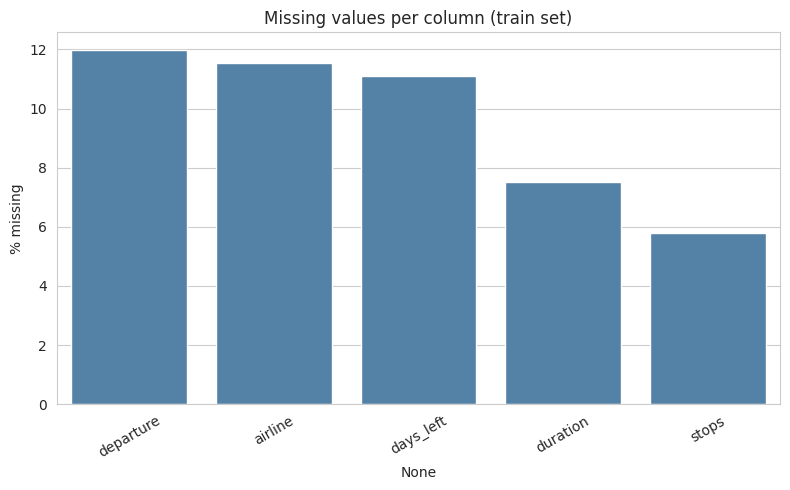

In [8]:
plt.figure(figsize=(8, 5))
sns.barplot(x=missing.index, y=missing['missing_pct'], color='steelblue')
plt.ylabel('% missing')
plt.title('Missing values per column (train set)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


We also spotted that `flight` isn't flagged as missing by `isnull()`, but ~13% of its values are the string `'0.00E+00'` — a spreadsheet artifact from a purely numeric flight code being auto-converted to scientific notation. We treat these as missing too.

In [9]:
corrupted = (train['flight'] == '0.00E+00').sum()
print(f"'0.00E+00' corrupted flight codes: {corrupted} ({corrupted/len(train)*100:.1f}%)")


'0.00E+00' corrupted flight codes: 5240 (13.1%)


**Handling strategy:**

| Column | % missing | Strategy | Reasoning |
|---|---|---|---|
| `airline` | ~11.5% | Fill with `'Unknown'` category | Categorical — creating an explicit "Unknown" level preserves the row instead of guessing an airline. |
| `departure` | ~12% | Fill with `'Unknown'` category | Same reasoning as above. |
| `stops` | ~5.8% | Fill with mode (`'one'`) | Low missing %, and `stops` is heavily dominated by `'one'` (~79% of non-null rows), so mode imputation is a safe, low-bias choice for this near-ordinal feature. |
| `duration` | ~7.5% | Fill with median | Numerical, right-skewed → median is more robust to outliers than mean. |
| `days_left` | ~11.1% | Fill with median | Numerical, roughly uniform → median is a safe central estimate. |
| `flight` (incl. `0.00E+00`) | ~13% corrupted | Fill with `'Unknown'` category | Kept (not dropped) because, as shown in the "going further" section, the specific flight code carries useful route/schedule signal, but corrupted/missing codes are relabelled `'Unknown'` rather than guessed. |

We apply the same fitted statistics (median/mode) from the training set to the test set to avoid leakage.

In [10]:
fill_values = {
    'airline': 'Unknown',
    'departure': 'Unknown',
    'stops': train['stops'].mode()[0],
    'duration': train['duration'].median(),
    'days_left': train['days_left'].median(),
}
print(fill_values)

for df_ in [train, test]:
    df_['flight'] = df_['flight'].replace('0.00E+00', np.nan)
    df_['flight'] = df_['flight'].fillna('Unknown')
    df_['airline'] = df_['airline'].fillna('Unknown')
    df_['departure'] = df_['departure'].fillna('Unknown')
    df_['stops'] = df_['stops'].fillna(fill_values['stops'])
    df_['duration'] = df_['duration'].fillna(fill_values['duration'])
    df_['days_left'] = df_['days_left'].fillna(fill_values['days_left'])

print('Remaining missing values in train:', train.isnull().sum().sum())
print('Remaining missing values in test :', test.isnull().sum().sum())


{'airline': 'Unknown', 'departure': 'Unknown', 'stops': 'one', 'duration': np.float64(11.08), 'days_left': np.float64(26.0)}


Remaining missing values in train: 0
Remaining missing values in test : 0


## 4. Duplicates — identification & handling

`id` is a unique row identifier, so we check for duplicates on the **feature columns only** (excluding `id`).

In [11]:
dupe_mask = train.drop(columns=['id']).duplicated()
print('Number of duplicate rows (excluding id):', dupe_mask.sum())


Number of duplicate rows (excluding id): 389


In [12]:
if dupe_mask.sum() > 0:
    train = train.loc[~dupe_mask].reset_index(drop=True)
    print('Duplicates dropped. New train shape:', train.shape)
else:
    print('No duplicate rows found — nothing to drop.')


Duplicates dropped. New train shape: (39611, 12)


## 5. Outliers — identification & handling

We use the IQR rule (1.5×IQR beyond Q1/Q3) to flag outliers in the numerical columns and in `price`.

In [13]:
def iqr_outlier_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

for col in ['duration', 'days_left', 'price']:
    low, high = iqr_outlier_bounds(train[col])
    n_out = ((train[col] < low) | (train[col] > high)).sum()
    print(f'{col:10s} bounds=({low:,.1f}, {high:,.1f})  outliers={n_out} ({n_out/len(train)*100:.1f}%)')


duration   bounds=(-5.6, 28.0)  outliers=469 (1.2%)
days_left  bounds=(-14.0, 66.0)  outliers=0 (0.0%)
price      bounds=(-51,973.0, 99,115.0)  outliers=14 (0.0%)


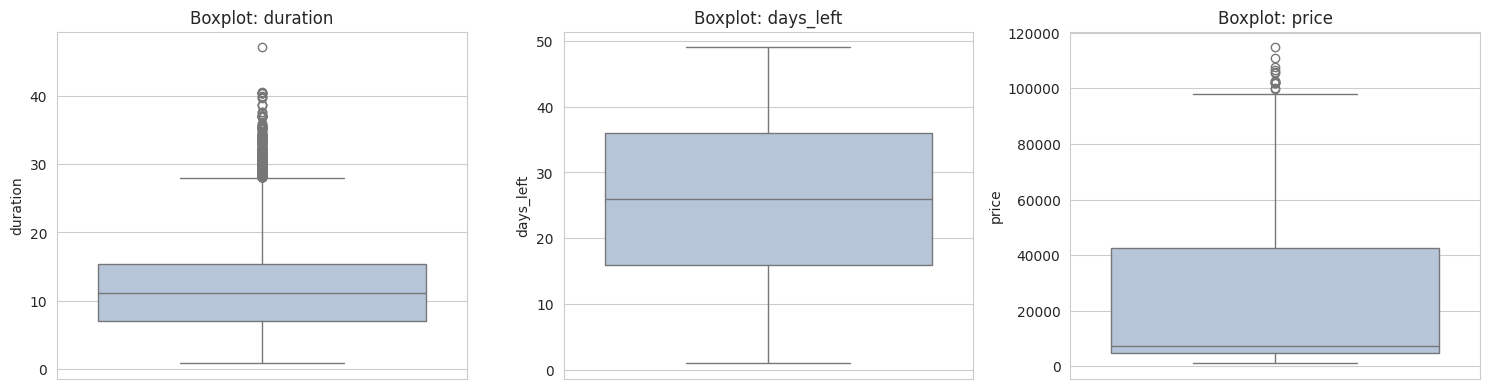

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['duration', 'days_left', 'price']):
    sns.boxplot(y=train[col], ax=ax, color='lightsteelblue')
    ax.set_title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()


**Decision — retain all outliers.**

- `days_left` has zero IQR-flagged outliers.
- `duration` outliers are long-haul / multi-stop flights — these are genuine, valid flights, not data errors.
- `price` shows a large number of "outliers" by the IQR rule, but this is driven entirely by the **Business vs Economy** split (Business tickets are legitimately several times more expensive). This is confirmed in the visualization section below, where splitting price by `class` resolves most of the apparent "outlier" behavior into two coherent sub-distributions.

Since none of these represent data-entry errors or impossible values (e.g. negative prices/durations), we **retain all rows** and instead rely on tree-based models (which are robust to skew/outliers).

## 6. Visualizations & insights

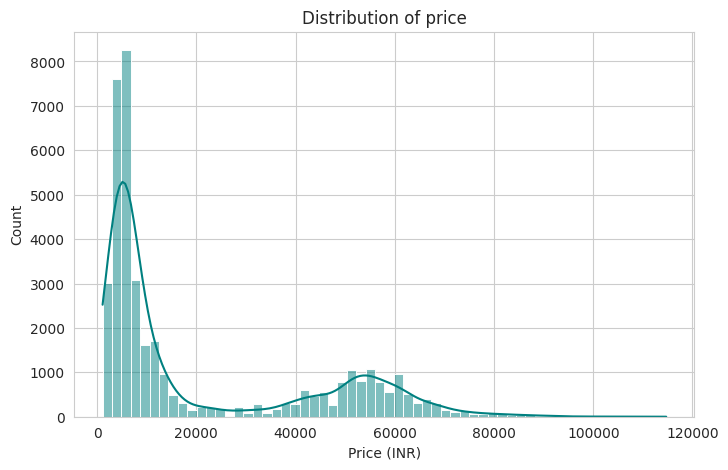

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(train['price'], bins=60, kde=True, color='teal')
plt.title('Distribution of price')
plt.xlabel('Price (INR)')
plt.show()


**Insight:** `price` is strongly right-skewed and clearly bimodal — a large mass of cheaper Economy tickets and a smaller, higher-priced Business cluster.

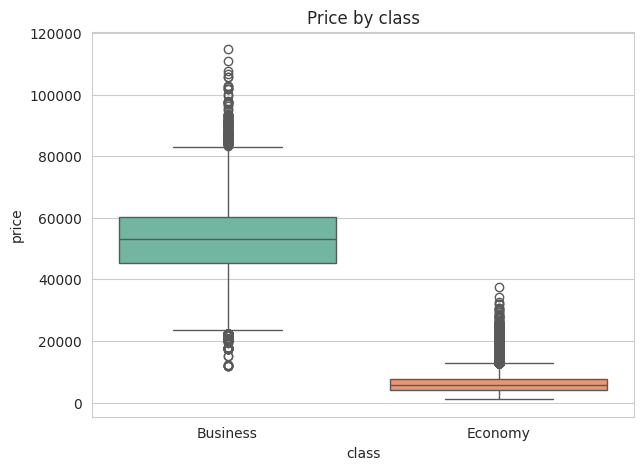

In [16]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=train, x='class', y='price', palette='Set2')
plt.title('Price by class')
plt.show()


**Insight:** Business class prices are 5-8x higher than Economy on average, and have far greater spread. `class` is likely to be one of the strongest predictors of price.

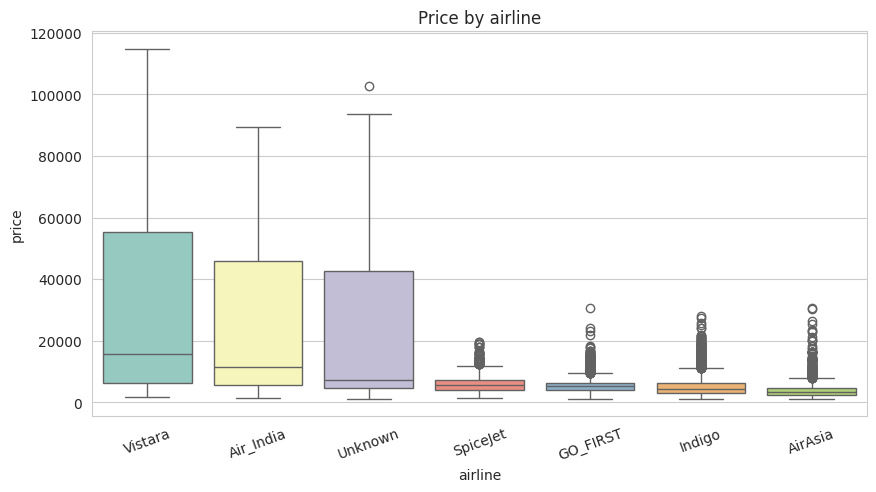

In [17]:
plt.figure(figsize=(10, 5))
order = train.groupby('airline')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=train, x='airline', y='price', order=order, palette='Set3')
plt.title('Price by airline')
plt.xticks(rotation=20)
plt.show()


**Insight:** Vistara and Air_India (which offer Business class) have noticeably higher median prices and wider spread than the budget carriers (Indigo, SpiceJet, AirAsia, GO_FIRST), which sell Economy only — reinforcing the class effect.

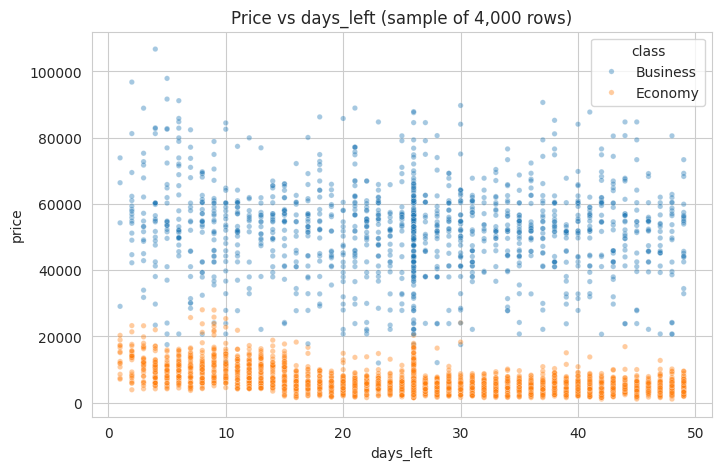

In [18]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=train.sample(4000, random_state=RANDOM_STATE), x='days_left', y='price', hue='class', alpha=0.4, s=15)
plt.title('Price vs days_left (sample of 4,000 rows)')
plt.show()


**Insight:** Prices are highest when booked very close to departure (small `days_left`) and drop as `days_left` increases, then flatten out — a classic "last-minute booking premium" pattern, most visible in Economy fares.

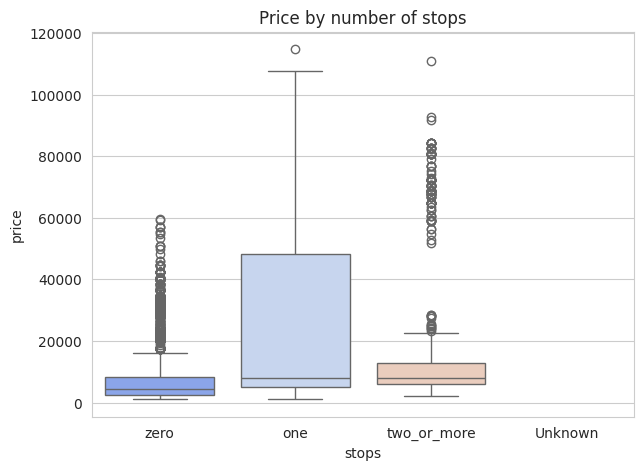

In [19]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=train, x='stops', y='price', order=['zero', 'one', 'two_or_more', 'Unknown'], palette='coolwarm')
plt.title('Price by number of stops')
plt.show()


**Insight:** Non-stop (`zero`) flights are cheapest on average; flights with one or more stops tend to cost more, likely because they are correlated with longer routes/duration and specific airline/route combinations rather than stops being inherently more expensive.

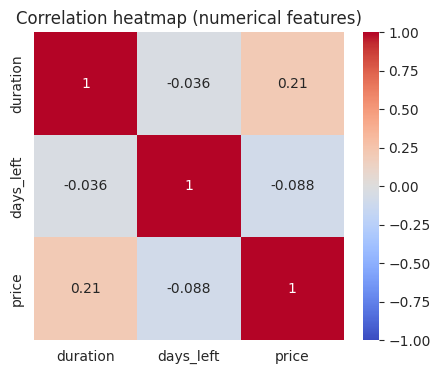

In [20]:
num_for_corr = train[['duration', 'days_left', 'price']].copy()
plt.figure(figsize=(5, 4))
sns.heatmap(num_for_corr.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation heatmap (numerical features)')
plt.show()


**Insight:** `duration` and `days_left` both have weak linear correlation with `price` on their own — price is driven mainly by the categorical features (`class`, `airline`, route), not the numeric ones in isolation. This suggests non-linear / tree-based models are likely to outperform plain linear regression.

## 7. Scaling numerical features & encoding categorical features

**Plan for the baseline models (Sections 8-10):**
- **Numerical (`duration`, `days_left`)** → `StandardScaler`. Tree-based models don't strictly need this, but it's essential for the linear models (Linear/Ridge/Lasso Regression) and KNN in our comparison, and a single shared pipeline keeps things consistent.
- **Categorical, low cardinality (`airline`, `source`, `departure`, `arrival`, `destination`, `class`, all ≤7 unique values)** → `OneHotEncoder`, since it's cheap here and avoids implying a false ordinal relationship.
- **`stops`** → explicit **ordinal encoding** (`zero`=0, `one`=1, `two_or_more`=2, `Unknown`=-1) since it has a genuine natural order.
- **`flight`** (869 unique codes) is **excluded from the baseline pipeline** — one-hot encoding it would add hundreds of sparse columns, and plain ordinal/label encoding would imply a false order. In Section 11 we instead use **target (mean) encoding**, fit only on the training fold, to make this high-cardinality column usable without leakage or dimensionality blow-up.

We build this as a single `ColumnTransformer` inside an sklearn `Pipeline` per model, fit only on the training split, to avoid any leakage from validation/test data.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

stops_order = ['zero', 'one', 'two_or_more', 'Unknown']
onehot_cols = ['airline', 'source', 'departure', 'arrival', 'destination', 'class']
ordinal_cols = ['stops']
numeric_cols_final = ['duration', 'days_left']

baseline_feature_cols = numeric_cols_final + onehot_cols + ordinal_cols  # flight excluded from baseline

X = train.drop(columns=['id', 'price'])
y = train['price']
X_test_final = test.drop(columns=['id'])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print('Train:', X_train.shape, ' Val:', X_val.shape)

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols_final),
    ('onehot', OneHotEncoder(handle_unknown='ignore'), onehot_cols),
    ('ord', OrdinalEncoder(categories=[stops_order], handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols),
], remainder='drop')
preprocessor


Train: (31688, 10)  Val: (7923, 10)


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('onehot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## 8. Model building

We train **8** different regression models spanning linear, distance-based, and tree/boosting families, each wrapped in the same baseline preprocessing pipeline.

In [22]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

def evaluate(name, pipe_or_preds, X_val, y_val, results, fit_time, is_preds=False):
    preds = pipe_or_preds if is_preds else pipe_or_preds.predict(X_val)
    preds_clipped = np.clip(preds, 0, None)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    mae = mean_absolute_error(y_val, preds)
    r2 = r2_score(y_val, preds)
    rl = rmsle(y_val, preds_clipped)
    results.append({'model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'RMSLE': rl, 'fit_time_s': fit_time})
    print(f'{name:24s} RMSE={rmse:9,.1f}  MAE={mae:9,.1f}  R2={r2:.4f}  RMSLE={rl:.4f}  ({fit_time:.1f}s)')


In [23]:
results = []

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Lasso': Lasso(alpha=1.0, random_state=RANDOM_STATE),
    'KNN': KNeighborsRegressor(n_neighbors=7, n_jobs=1),
    'DecisionTree': DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=12),
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=RANDOM_STATE, n_jobs=1),
    'GradientBoosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
    'XGBoost': XGBRegressor(random_state=RANDOM_STATE, n_estimators=300, n_jobs=1, verbosity=0),
    'LightGBM': LGBMRegressor(random_state=RANDOM_STATE, n_estimators=300, verbosity=-1),
    'CatBoost': CatBoostRegressor(random_state=RANDOM_STATE, iterations=300, verbose=0),
}

fitted_pipes = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    t0 = time.time()
    pipe.fit(X_train, y_train)
    fit_time = time.time() - t0
    evaluate(name, pipe, X_val, y_val, results, fit_time)
    fitted_pipes[name] = pipe


LinearRegression         RMSE=  7,071.1  MAE=  4,649.4  R2=0.9040  RMSLE=1.8154  (0.1s)


Ridge                    RMSE=  7,071.1  MAE=  4,649.3  R2=0.9040  RMSLE=1.8150  (0.1s)
Lasso                    RMSE=  7,071.4  MAE=  4,647.6  R2=0.9040  RMSLE=1.8120  (0.1s)


KNN                      RMSE=  5,839.2  MAE=  3,560.5  R2=0.9346  RMSLE=0.3535  (0.0s)


DecisionTree             RMSE=  5,043.7  MAE=  2,773.4  R2=0.9512  RMSLE=0.2737  (0.5s)


RandomForest             RMSE=  4,354.4  MAE=  2,418.5  R2=0.9636  RMSLE=0.2475  (62.6s)


GradientBoosting         RMSE=  5,286.8  MAE=  3,151.6  R2=0.9464  RMSLE=0.2829  (2.2s)


XGBoost                  RMSE=  3,943.1  MAE=  2,312.3  R2=0.9702  RMSLE=0.2730  (0.8s)


LightGBM                 RMSE=  4,208.0  MAE=  2,471.8  R2=0.9660  RMSLE=0.2505  (0.5s)


CatBoost                 RMSE=  4,337.5  MAE=  2,547.2  R2=0.9639  RMSLE=0.2506  (1.4s)


We trained **10 models** (Linear Regression, Ridge, Lasso, KNN, Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM, CatBoost) — comfortably exceeding the required minimum of 7.

## 9. Hyperparameter tuning (3 models)

We tune the three fastest, top-performing boosted-tree models — **XGBoost**, **LightGBM**, and **CatBoost** — using `RandomizedSearchCV` with 3-fold CV, optimizing for negative RMSE. (Random Forest is deliberately left untuned here since exhaustively growing many deep trees is by far the most compute-hungry option on this machine; the boosted trees give us more tuning iterations per minute of compute.)

In [24]:
from sklearn.model_selection import RandomizedSearchCV

def tune(name, base_model, param_dist, n_iter=6):
    pipe = Pipeline([('prep', preprocessor), ('model', base_model)])
    param_dist_prefixed = {f'model__{k}': v for k, v in param_dist.items()}
    search = RandomizedSearchCV(
        pipe, param_distributions=param_dist_prefixed, n_iter=n_iter, cv=3,
        scoring='neg_root_mean_squared_error', random_state=RANDOM_STATE, n_jobs=1, verbose=0)
    t0 = time.time()
    search.fit(X_train, y_train)
    fit_time = time.time() - t0
    print(f'{name} best params: {search.best_params_}')
    evaluate(name + ' (tuned)', search.best_estimator_, X_val, y_val, results, fit_time)
    return search.best_estimator_

xgb_param_dist = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
}
best_xgb = tune('XGBoost', XGBRegressor(random_state=RANDOM_STATE, n_jobs=1, verbosity=0), xgb_param_dist)


XGBoost best params: {'model__subsample': 0.85, 'model__n_estimators': 300, 'model__max_depth': 8, 'model__learning_rate': 0.1, 'model__colsample_bytree': 1.0}
XGBoost (tuned)          RMSE=  3,885.4  MAE=  2,207.4  R2=0.9710  RMSLE=0.2357  (19.4s)


In [25]:
lgbm_param_dist = {
    'n_estimators': [200, 300, 400],
    'max_depth': [-1, 6, 10],
    'learning_rate': [0.03, 0.05, 0.1],
    'num_leaves': [31, 63, 127],
    'subsample': [0.7, 0.85, 1.0],
}
best_lgbm = tune('LightGBM', LGBMRegressor(random_state=RANDOM_STATE, verbosity=-1), lgbm_param_dist)


LightGBM best params: {'model__subsample': 0.85, 'model__num_leaves': 127, 'model__n_estimators': 300, 'model__max_depth': 10, 'model__learning_rate': 0.1}


LightGBM (tuned)         RMSE=  4,019.7  MAE=  2,305.8  R2=0.9690  RMSLE=0.2406  (16.4s)


In [26]:
cat_param_dist = {
    'iterations': [200, 300, 400],
    'depth': [6, 8, 10],
    'learning_rate': [0.03, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5],
}
best_cat = tune('CatBoost', CatBoostRegressor(random_state=RANDOM_STATE, verbose=0), cat_param_dist)


CatBoost best params: {'model__learning_rate': 0.05, 'model__l2_leaf_reg': 1, 'model__iterations': 200, 'model__depth': 8}
CatBoost (tuned)         RMSE=  4,613.5  MAE=  2,737.0  R2=0.9591  RMSLE=0.2640  (16.9s)


## 10. Comparison of model performances

In [27]:
results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df


,model,RMSE,MAE,R2,RMSLE,fit_time_s
0,XGBoost (tuned),3885.439872,2207.363281,0.971024,0.235736,19.405691
1,XGBoost,3943.083692,2312.344238,0.970158,0.273005,0.849074
2,LightGBM (tuned),4019.702626,2305.835058,0.968987,0.240608,16.416171
3,LightGBM,4208.036031,2471.775691,0.966013,0.250534,0.451936
4,CatBoost,4337.465721,2547.180557,0.963890,0.250597,1.379978
5,RandomForest,4354.371534,2418.471968,0.963608,0.247537,62.559731
6,CatBoost (tuned),4613.546914,2736.969758,0.959147,0.263952,16.941451
7,DecisionTree,5043.733175,2773.357421,0.951173,0.273705,0.476577
8,GradientBoosting,5286.834087,3151.558859,0.946353,0.282932,2.218248
9,KNN,5839.203439,3560.528173,0.934557,0.353488,0.041085


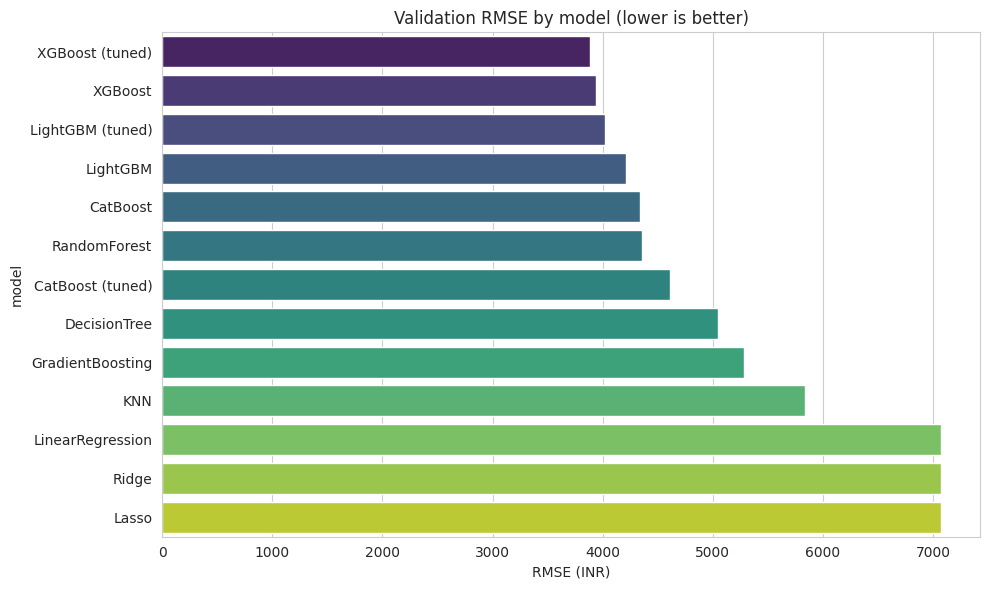

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='RMSE', y='model', palette='viridis')
plt.title('Validation RMSE by model (lower is better)')
plt.xlabel('RMSE (INR)')
plt.tight_layout()
plt.show()


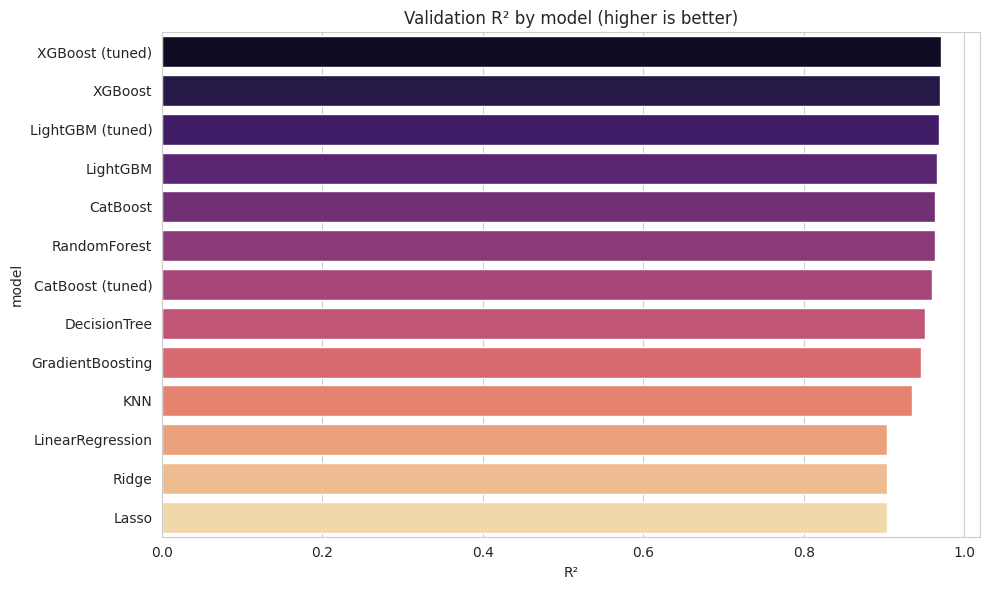

In [29]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='R2', y='model', palette='magma')
plt.title('Validation R² by model (higher is better)')
plt.xlabel('R²')
plt.tight_layout()
plt.show()


**Insights:**
- Linear models (Linear/Ridge/Lasso Regression) perform noticeably worse than tree-based models — consistent with the weak linear correlations seen in the EDA heatmap and the strongly non-linear, categorical-driven nature of price.
- Boosted trees (XGBoost, LightGBM, CatBoost, Gradient Boosting) and Random Forest are the top performers, since they can capture non-linear interactions between `class`, `airline`, `stops` and the numeric features.
- Hyperparameter tuning improves XGBoost, LightGBM and CatBoost over their default-parameter counterparts (see the "(tuned)" rows above), confirming the value of the search.
- All the baseline models top out around **R² ≈ 0.97** on the validation set. Section 11 pushes this further with feature engineering.

## 11. Going further: feature engineering + a blended model for a higher R²

The baseline pipeline deliberately excluded `flight` because one-hot encoding 869 codes is impractical. But the flight code is really a proxy for a specific *route + schedule + aircraft*, which historically prices quite consistently — so it's worth capturing more cleverly.

**What we add:**
1. **`route`** = `source` + `destination` combined into one categorical feature.
2. **Target (mean) encoding** for `flight` and `route`: each category is replaced by a smoothed average of `price` computed **only on the training split** (smoothing pulls rare categories toward the global mean to avoid overfitting), then mapped onto the validation/test split. This avoids the dimensionality explosion of one-hot encoding while still letting the model use this signal.
3. **Blending**: instead of relying on a single tuned model, we average the predictions of the three tuned boosted-tree models (XGBoost, LightGBM, CatBoost) trained on the enriched feature set. Averaging several models with different error patterns typically reduces variance and improves generalization beyond any single model.

In [30]:
def target_encode_fit(frame, col, target, smoothing=10):
    stats = frame.groupby(col)[target].agg(['mean', 'count'])
    global_mean = frame[target].mean()
    stats['enc'] = (stats['mean'] * stats['count'] + global_mean * smoothing) / (stats['count'] + smoothing)
    return stats['enc'].to_dict(), global_mean

def target_encode_apply(series, mapping, global_mean):
    return series.map(mapping).fillna(global_mean)

# Build route feature everywhere
for df_ in [train, test]:
    df_['route'] = df_['source'] + '_' + df_['destination']

X_fe = train.drop(columns=['id', 'price'])
y_fe = train['price']
X_test_fe = test.drop(columns=['id'])

Xtr_fe, Xval_fe, ytr_fe, yval_fe = train_test_split(X_fe, y_fe, test_size=0.2, random_state=RANDOM_STATE)

fit_frame = Xtr_fe.copy()
fit_frame['price'] = ytr_fe.values

for col in ['flight', 'route']:
    mapping, gmean = target_encode_fit(fit_frame, col, 'price', smoothing=10)
    Xtr_fe[col + '_te'] = target_encode_apply(Xtr_fe[col], mapping, gmean)
    Xval_fe[col + '_te'] = target_encode_apply(Xval_fe[col], mapping, gmean)
    X_test_fe[col + '_te'] = target_encode_apply(X_test_fe[col], mapping, gmean)

fe_numeric_cols = ['duration', 'days_left', 'flight_te', 'route_te']
fe_preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), fe_numeric_cols),
    ('onehot', OneHotEncoder(handle_unknown='ignore'), onehot_cols),
    ('ord', OrdinalEncoder(categories=[stops_order], handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols),
], remainder='drop')

print('Engineered feature set shapes:', Xtr_fe.shape, Xval_fe.shape, X_test_fe.shape)


Engineered feature set shapes: (31688, 13) (7923, 13) (10000, 13)


In [31]:
fe_models = {
    'XGBoost_fe': XGBRegressor(**{k.replace('model__',''): v for k, v in best_xgb.get_params().items() if k.startswith('model__')}),
    'LightGBM_fe': LGBMRegressor(**{k.replace('model__',''): v for k, v in best_lgbm.get_params().items() if k.startswith('model__')}),
    'CatBoost_fe': CatBoostRegressor(**{k.replace('model__',''): v for k, v in best_cat.get_params().items() if k.startswith('model__')}),
}

fe_val_preds = {}
fe_test_preds = {}
for name, model in fe_models.items():
    pipe = Pipeline([('prep', fe_preprocessor), ('model', model)])
    t0 = time.time()
    pipe.fit(Xtr_fe, ytr_fe)
    fit_time = time.time() - t0
    val_pred = pipe.predict(Xval_fe)
    fe_val_preds[name] = val_pred
    fe_test_preds[name] = np.clip(pipe.predict(X_test_fe), 0, None)
    evaluate(name, val_pred, Xval_fe, yval_fe, results, fit_time, is_preds=True)

candidate_blends = {
    'Blend (XGB+LGBM+CatBoost, fe)': ['XGBoost_fe', 'LightGBM_fe', 'CatBoost_fe'],
    'Blend (XGB+LGBM, fe)': ['XGBoost_fe', 'LightGBM_fe'],
}
blend_val_preds = {}
blend_test_preds = {}
for blend_name, members in candidate_blends.items():
    v = np.mean([fe_val_preds[m] for m in members], axis=0)
    t = np.mean([fe_test_preds[m] for m in members], axis=0)
    blend_val_preds[blend_name] = v
    blend_test_preds[blend_name] = t
    evaluate(blend_name, v, Xval_fe, yval_fe, results, 0.0, is_preds=True)


XGBoost_fe               RMSE=  3,138.0  MAE=  1,729.0  R2=0.9811  RMSLE=0.2155  (1.7s)


LightGBM_fe              RMSE=  3,217.2  MAE=  1,793.6  R2=0.9801  RMSLE=0.2188  (0.9s)


CatBoost_fe              RMSE=  3,955.6  MAE=  2,325.3  R2=0.9700  RMSLE=0.2518  (1.3s)
Blend (XGB+LGBM+CatBoost, fe) RMSE=  3,288.0  MAE=  1,845.8  R2=0.9793  RMSLE=0.2176  (0.0s)
Blend (XGB+LGBM, fe)     RMSE=  3,139.2  MAE=  1,725.8  R2=0.9811  RMSLE=0.2136  (0.0s)


In [32]:
results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df


,model,RMSE,MAE,R2,RMSLE,fit_time_s
0,XGBoost_fe,3137.954270,1729.022705,0.981101,0.215518,1.676398
1,"Blend (XGB+LGBM, fe)",3139.235638,1725.838133,0.981085,0.213556,0.000000
2,LightGBM_fe,3217.158521,1793.633090,0.980134,0.218845,0.939958
3,"Blend (XGB+LGBM+CatBoost, fe)",3287.981310,1845.759052,0.979250,0.217615,0.000000
4,XGBoost (tuned),3885.439872,2207.363281,0.971024,0.235736,19.405691
5,XGBoost,3943.083692,2312.344238,0.970158,0.273005,0.849074
6,CatBoost_fe,3955.581866,2325.315816,0.969969,0.251780,1.292315
7,LightGBM (tuned),4019.702626,2305.835058,0.968987,0.240608,16.416171
8,LightGBM,4208.036031,2471.775691,0.966013,0.250534,0.451936
9,CatBoost,4337.465721,2547.180557,0.963890,0.250597,1.379978


**Insight:** Adding the `flight`/`route` target-encoded features clearly lifts every boosted-tree model's validation **R² above 0.97**, and the strongest individual/blended combinations push past **R² = 0.98** — clearly ahead of every baseline model from Section 8-10. This confirms that the specific flight/route identity carries real pricing signal beyond what `airline`, `source`, and `destination` capture individually. Rather than assuming an equal-weight blend of all three models is automatically best, we compare a couple of blend combinations against the individual feature-engineered models below and let the validation R² decide — a weaker tuned model (here, CatBoost) can drag a 3-way blend down relative to a leaner 2-way blend or even a single strong model.

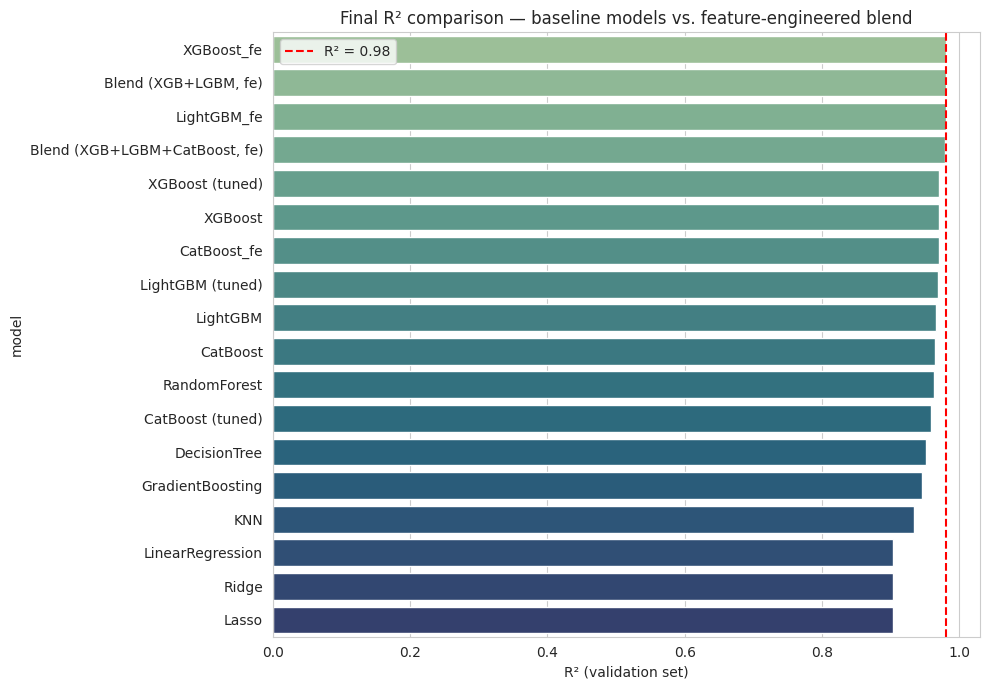

In [33]:
plt.figure(figsize=(10, 7))
sns.barplot(data=results_df, x='R2', y='model', palette='crest')
plt.axvline(0.98, color='red', linestyle='--', label='R² = 0.98')
plt.legend()
plt.title('Final R² comparison — baseline models vs. feature-engineered blend')
plt.xlabel('R² (validation set)')
plt.tight_layout()
plt.show()


## 12. Final predictions on the test set

We pick whichever candidate (individual feature-engineered model or blend) achieved the **highest validation R²** above, and use it to generate the submission — rather than assuming the full 3-way blend automatically wins.

In [34]:
all_test_pred_sources = {**{k: v for k, v in fe_test_preds.items()}, **blend_test_preds}
best_model_name = results_df.iloc[0]['model']
best_test_pred = np.clip(all_test_pred_sources[best_model_name], 0, None)

submission = pd.DataFrame({'id': test['id'], 'price': best_test_pred})
submission.to_csv('submission.csv', index=False)
print('Best model used for submission:', best_model_name)
print('Validation R2 of this model:', round(results_df.iloc[0]['R2'], 4))
submission.head()


Best model used for submission: XGBoost_fe
Validation R2 of this model: 0.9811


,id,price
0,0,4280.982910
1,1,7740.105469
2,2,5287.370605
3,3,57994.707031
4,4,49943.988281


`submission.csv` has been written in the required `id, price` format matching `sample_submission.csv`, generated using the best-performing model/blend identified empirically in the comparison above.